In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

Data Wrangling

In [4]:
# Load data
df = pd.read_csv('data/employee_data.csv')

# Cek informasi data
print(df.info())

# Menangani missing values pada target 'Attrition'
# Karena ini variabel penting, kita hapus baris yang Attrition-nya kosong
df = df.dropna(subset=['Attrition'])

# Menghapus kolom yang tidak memberikan informasi (hanya satu nilai)
df = df.drop(['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeId'], axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

Exploratory Data Analysis (EDA)

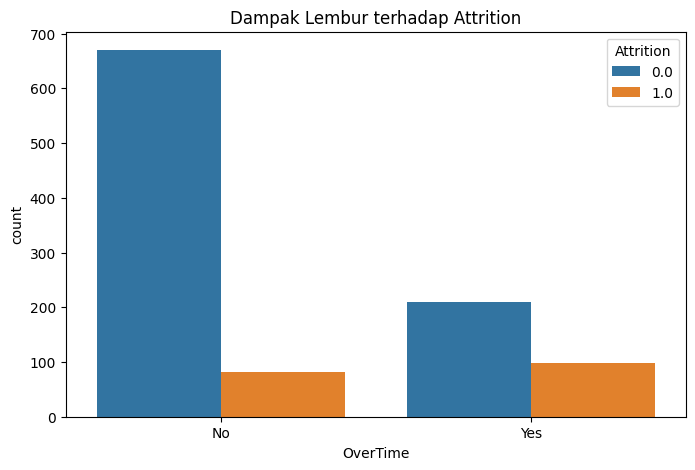

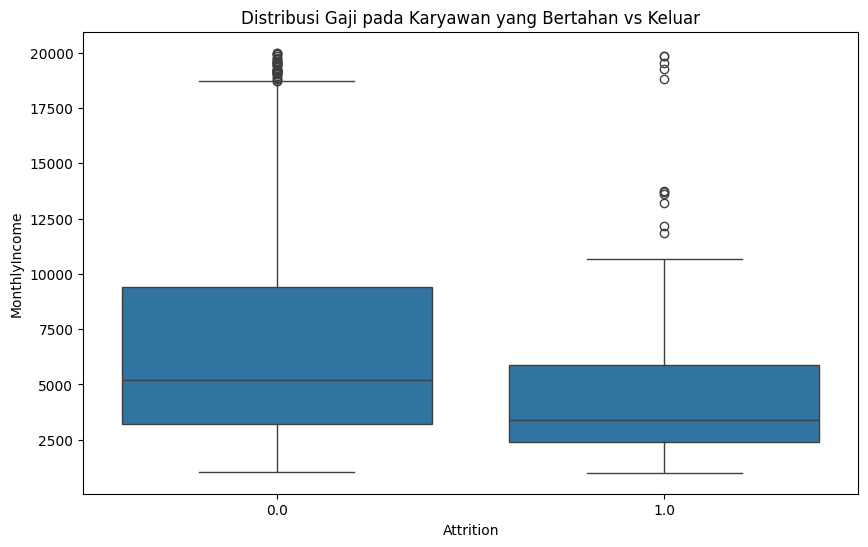

In [5]:
# Visualisasi 1: Attrition berdasarkan OverTime
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('Dampak Lembur terhadap Attrition')
plt.show()

# Visualisasi 2: Hubungan Gaji dan Attrition
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('Distribusi Gaji pada Karyawan yang Bertahan vs Keluar')
plt.show()

Data Preparation (Feature Engineering)

In [6]:
# Mengubah kolom kategori menjadi angka
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Memisahkan fitur (X) dan target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Modeling (Machine Learning)

In [7]:
# Membuat Model Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluasi Model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.84      1.00      0.92       173
         1.0       1.00      0.18      0.30        39

    accuracy                           0.85       212
   macro avg       0.92      0.59      0.61       212
weighted avg       0.87      0.85      0.80       212



Kesimpulan Bisnis (Markdown)
Tuliskan kesimpulan di akhir notebook untuk mempermudah saat pembuatan video:

Kesimpulan: Faktor utama attrition adalah gaji yang rendah dan lembur yang berlebihan.

Rekomendasi: Perusahaan harus meninjau ulang kebijakan lembur dan memberikan insentif bagi posisi dengan tingkat stres tinggi.